In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
d2h = pd.read_csv("Data_transfer_D2H_miro.txt", 
                 delim_whitespace=True,
                    comment='M',
                 skiprows=1, 
                 names=["data", "time", "transfer"])
d2h["transfer"] = d2h["transfer"] / 1e9

h2d = pd.read_csv("Data_transfer_H2D_miro.txt", 
                 delim_whitespace=True,
                  comment='M',
                 skiprows=1, 
                 names=["data", "time", "transfer"])
h2d["transfer"] = h2d["transfer"] / 1e9

d2d = pd.read_csv("Data_transfer_D2D_miro.txt", 
                 delim_whitespace=True,
                 skiprows=1, 
                 names=["data", "time", "transfer"])
d2d["transfer"] = d2d["transfer"] / 1e9


/tmp/ipykernel_1809164/1143504399.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  d2h = pd.read_csv("Data_transfer_D2H_miro.txt",
/tmp/ipykernel_1809164/1143504399.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  h2d = pd.read_csv("Data_transfer_H2D_miro.txt",
/tmp/ipykernel_1809164/1143504399.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  d2d = pd.read_csv("Data_transfer_D2D_miro.txt",


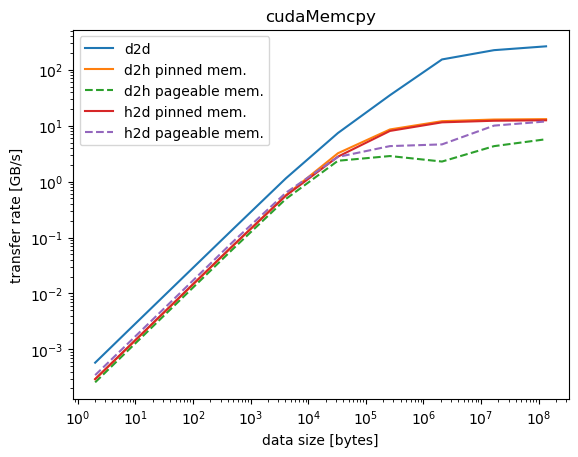

In [17]:
plt.plot(d2d['data'], d2d['transfer'], label='d2d')
plt.plot(d2h['data'][10:], d2h['transfer'][10:], label='d2h pinned mem.')
plt.plot(d2h['data'][:10], d2h['transfer'][:10], '--', label='d2h pageable mem.')
plt.plot(h2d['data'][10:], h2d['transfer'][10:], label='h2d pinned mem.')
plt.plot(h2d['data'][:10], h2d['transfer'][:10], '--', label='h2d pageable mem.')


plt.xscale('log')
plt.yscale('log')
plt.title('cudaMemcpy')
plt.xlabel('data size [bytes]')
plt.ylabel('transfer rate [GB/s]')
plt.legend()
plt.savefig('cudaMemcpy.pdf')
plt.show()

In [63]:
d2d_threads = pd.read_csv("coalesced_memory_access_results_threads.txt", 
                         delimiter=",",
                         skiprows=1, 
                         names=["data", "threads", "transfer"])

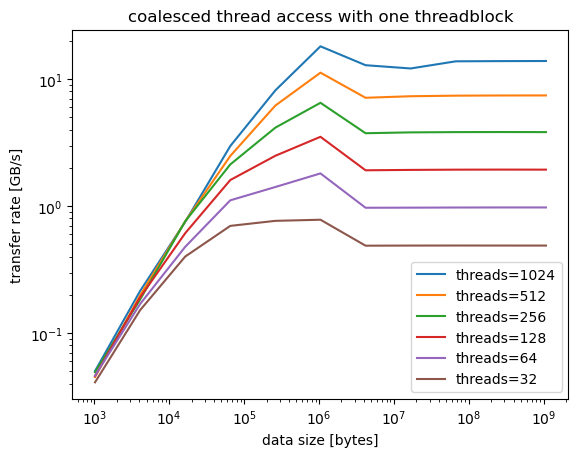

In [99]:
for threads_val in sorted(d2d_threads['threads'].unique(), reverse=True):
    subset = d2d_threads[d2d_threads['threads'] == threads_val]
    plt.plot(subset['data'], subset['transfer'], label=f"threads={int(threads_val)}")

plt.xscale('log')
plt.yscale('log')
plt.xlabel('data size [bytes]')
plt.ylabel('transfer rate [GB/s]')
plt.title('coalesced thread access with one threadblock')
plt.legend()
plt.savefig('coalesced_thread_access_a.pdf')
plt.show()

In [66]:
d2d_threadblocks = pd.read_csv("coalesced_memory_access_results_threadblocks.txt", 
                         delimiter=",",
                         skiprows=1, 
                         names=["data", "threads", "threadblocks", "transfer"])

In [67]:
d2d_threadblocks['data'][0::5]

0           1024
5           4096
10         16384
15         65536
20        262144
25       1048576
30       4194304
35      16777216
40      67108864
45     268435456
50    1073741824
Name: data, dtype: int64

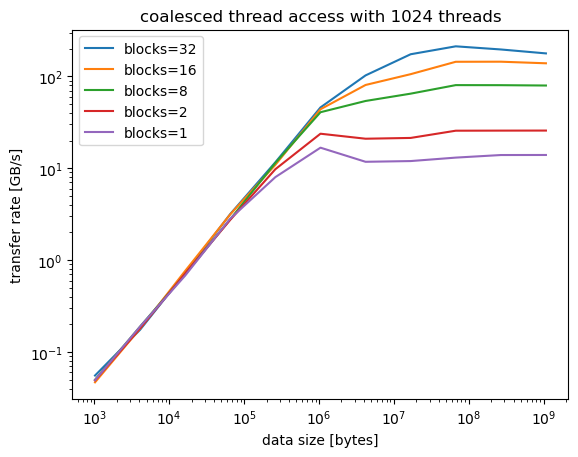

In [98]:
for threadsblock in sorted(d2d_threadblocks['threadblocks'].unique(), reverse=True):
    subset = d2d_threadblocks[d2d_threadblocks['threadblocks'] == threadsblock]
    plt.plot(subset['data'], subset['transfer'], label=f"blocks={int(threadsblock)}")

plt.xscale('log')
plt.yscale('log')
plt.xlabel('data size [bytes]')
plt.ylabel('transfer rate [GB/s]')
plt.title('coalesced thread access with 1024 threads')
plt.legend()
plt.savefig('coalesced_thread_access_b.pdf')
plt.show()

In [87]:
strided_memory_access = pd.read_csv("strided_memory_access_results.txt", 
                         delimiter=",",
                         skiprows=1, 
                         names=["stride", "threads", "threadblocks", "transfer"])

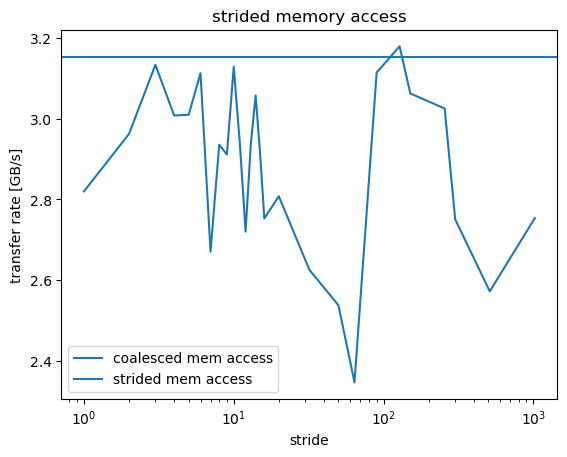

In [104]:

plt.axhline(y=d2d_threadblocks['transfer'][18], label="coalesced mem access")
plt.plot(strided_memory_access['stride'], strided_memory_access['transfer'], label="strided mem access")
plt.xlabel('stride')
plt.ylabel('transfer rate [GB/s]')
plt.title('strided memory access')
plt.legend()
plt.xscale('log')
plt.savefig('strided_thread_access.pdf')
plt.show()

In [97]:
offset_memory_access = pd.read_csv("offset_memory_access_results.txt", 
                         delimiter=",",
                         skiprows=1, 
                         names=["offset", "threads", "threadblocks", "transfer"])

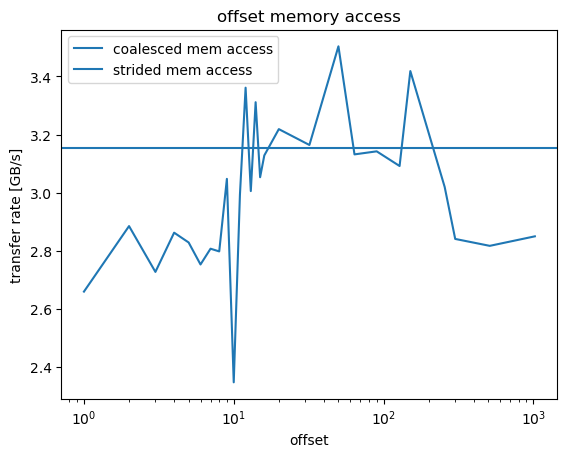

In [105]:
plt.axhline(y=d2d_threadblocks['transfer'][18], label="coalesced mem access")
plt.plot(offset_memory_access['offset'], offset_memory_access['transfer'], label="strided mem access")
plt.xlabel('offset')
plt.ylabel('transfer rate [GB/s]')
plt.title('offset memory access')
plt.legend()
plt.xscale('log')
plt.savefig('offset_thread_access.pdf')
plt.show()